In [1]:
from ssod.apis.inference import init_detector, inference_detector, save_result
import matplotlib.pyplot as plt
import mmcv
import numpy as np
import scipy.io as sio
import os
import scipy
from scipy.optimize import linear_sum_assignment
import re
import pandas as pd
import cv2

In [12]:
num_classes = 6
model = init_detector( config = "/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output/worked_cfg.py",
                        checkpoint = "/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output/epoch_21.pth")


model.inference_on = "globals"
thr = 0.5


load checkpoint from local path: /rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output/epoch_21.pth


In [10]:
val_folder = "/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/qpproj/finetuning/validation"

val_roi_folder = os.path.join(val_folder,"roi")
val_roi_files = os.listdir(val_roi_folder)
output_folder = os.path.join(val_folder,"predictions")
os.makedirs(output_folder, exist_ok=True)

In [13]:
#single image pred
tile_path =os.path.join(val_roi_folder,val_roi_files[0])
den_pred = inference_detector(model, tile_path)

In [5]:
class_colors = {
    1: [255, 0, 255],
    2: [0, 255, 0],
    3: [0, 0, 255],
    4: [0, 255, 255],
    5: [255, 0, 0],
    6: [255, 255, 0]
}

class_names = {
   'neutrophil':1,
   'epithelium':2,
   'lymphocyte':3,
   'plasma':4,
   'eosinophil':5,
   'stroma':6}

In [6]:
model.CLASSES

('Neutrophil',
 'Epithelial',
 'Lymphocyte',
 'Plasma',
 'Eosinophil',
 'Connective')

In [7]:

pred_centroid = []
pred_inst_type = []

for i in range(num_classes):
    classes = den_pred[i][np.where(den_pred[i][:, 2] > thr)]
    classes = classes[:, :2]
    pred_centroid.extend(classes)
    pred_type = np.full((classes.shape[0], 1), i + 1)
    pred_inst_type.extend(pred_type)

tile_data_pred = np.hstack((pred_centroid, pred_inst_type))
tile_data_pred = tile_data_pred.astype(int)

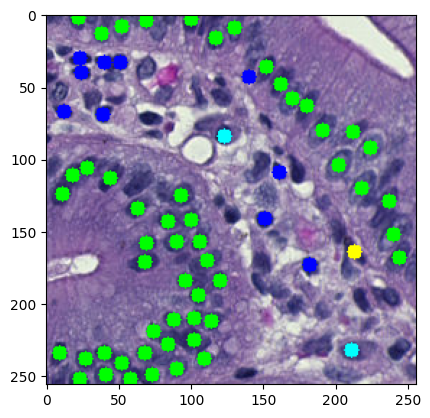

In [ ]:
df = pd.DataFrame(tile_data_pred, columns=['x', 'y', 'class'])

tile_image = cv2.imread(tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)

        
# Overlay each detection
for _, row in df.iterrows():
    color = class_colors[row['class']]
    x, y = int(row['x']), int(row['y'])
    tile_image = cv2.circle(tile_image, (x, y), radius=5, color=color, thickness=-1)
plt.imshow(tile_image)


In [15]:
true_folder = os.path.join(val_folder,"csv")

den_true_path = os.path.join(true_folder,os.path.splitext(val_roi_files[0])[0]+'.csv')

den_true_data = pd.read_csv(den_true_path)
den_true_data

,x,y,class
0,215.292969,164.804688,stroma
1,173.474609,109.726562,stroma
2,215.972656,230.422852,stroma
3,153.076172,72.667969,stroma
4,242.662109,169.054688,epithelium
...,...,...,...
102,148.316406,188.603516,lymphocyte
103,149.675781,172.625000,lymphocyte
104,156.474609,188.603516,lymphocyte
105,169.394531,199.823242,lymphocyte


In [16]:
den_true_data['inst_type'] = den_true_data['class'].map(class_names)
den_true_data

,x,y,class,inst_type
0,215.292969,164.804688,stroma,6
1,173.474609,109.726562,stroma,6
2,215.972656,230.422852,stroma,6
3,153.076172,72.667969,stroma,6
4,242.662109,169.054688,epithelium,2
...,...,...,...,...
102,148.316406,188.603516,lymphocyte,3
103,149.675781,172.625000,lymphocyte,3
104,156.474609,188.603516,lymphocyte,3
105,169.394531,199.823242,lymphocyte,3


In [17]:
true_centroid_x = (den_true_data["x"]).astype("float32")
true_centroid_y = (den_true_data["y"]).astype("float32")
true_centroid = np.vstack((true_centroid_x, true_centroid_y))
true_inst_type = (den_true_data["inst_type"]).astype("int32")

In [18]:
pred_centroid = np.asarray(pred_centroid).astype("float32")
pred_inst_type = np.asarray(pred_inst_type).astype("int32")

In [20]:
true_centroid_array = true_centroid.T
true_centroid_array

array([[215.29297  , 164.80469  ],
       [173.47461  , 109.72656  ],
       [215.97266  , 230.42285  ],
       [153.07617  ,  72.66797  ],
       [242.66211  , 169.05469  ],
       [240.96289  , 152.05566  ],
       [234.16211  , 135.39551  ],
       [233.14258  , 116.0166   ],
       [218.52344  , 119.07617  ],
       [202.54297  , 104.11719  ],
       [222.94336  ,  91.87793  ],
       [241.64258  , 106.49707  ],
       [211.38281  ,  82.69824  ],
       [188.94336  ,  79.29785  ],
       [180.44531  ,  60.938477 ],
       [170.92578  ,  56.8584   ],
       [163.44531  ,  46.999023 ],
       [151.88477  ,  37.479492 ],
       [146.10547  ,  27.95996  ],
       [131.14648  ,   9.600586 ],
       [118.22656  ,  16.740234 ],
       [ 98.50781  ,   4.5009766],
       [ 78.44922  ,   8.920898 ],
       [ 65.86914  ,   3.4804688],
       [ 52.94922  ,   8.920898 ],
       [ 44.109375 ,   3.8203125],
       [ 37.310547 ,  13.       ],
       [ 32.55078  ,   2.1210938],
       [ 20.310547 ,

In [21]:
pred_centroid_array = np.squeeze(np.array(pred_centroid))
pred_centroid_array

array([[ 27.470604 , 238.77255  ],
       [ 90.27613  , 157.00589  ],
       [224.7294   ,  92.9151   ],
       [ 93.9302   , 125.44788  ],
       [ 44.59773  , 113.9535   ],
       [111.95164  , 170.64218  ],
       [162.26155  ,  48.119125 ],
       [ 68.49391  , 171.1463   ],
       [244.0828   , 168.60414  ],
       [218.71396  , 120.56148  ],
       [ 40.50216  , 234.1019   ],
       [ 52.638317 , 241.06294  ],
       [130.01158  ,   9.454698 ],
       [180.71768  ,  63.334373 ],
       [ 68.8679   , 234.45087  ],
       [191.26794  ,  80.23706  ],
       [ 52.49744  ,   8.304729 ],
       [202.58582  , 104.739655 ],
       [ 63.367664 , 134.02333  ],
       [ 41.10204  , 249.61127  ],
       [170.46942  ,  58.654415 ],
       [120.146706 , 184.10518  ],
       [114.948044 , 212.13797  ],
       [ 88.5552   , 211.17627  ],
       [ 84.82981  , 143.08278  ],
       [105.033035 , 194.69753  ],
       [102.65756  , 210.1052   ],
       [ 84.50136  , 228.01007  ],
       [102.74621  ,

In [22]:
paired, unpaired_true, unpaired_pred = pair_coordinates(
        true_centroid_array, pred_centroid, 6
    )

In [23]:

paired_true_type = true_inst_type[paired[:, 0]]
paired_pred_type = pred_inst_type[paired[:, 1]]
unpaired_true_type = true_inst_type[unpaired_true]
unpaired_pred_type = pred_inst_type[unpaired_pred]

In [59]:
def _f1_type(paired_true, paired_pred, unpaired_true, unpaired_pred, type_id, w):
    type_samples = (paired_true == type_id) | (paired_pred == type_id)

    paired_true = paired_true[type_samples[0]]
    paired_pred = paired_pred[type_samples[0]]

    tp_dt = ((paired_true == type_id) & (paired_pred == type_id)).sum()
    tn_dt = ((paired_true != type_id) & (paired_pred != type_id)).sum()
    fp_dt = ((paired_true != type_id) & (paired_pred == type_id)).sum()
    fn_dt = ((paired_true == type_id) & (paired_pred != type_id)).sum()

    fp_d = (unpaired_pred == type_id).sum()
    fn_d = (unpaired_true == type_id).sum()

    f1_type = (2 * (tp_dt + tn_dt)) / (
            2 * (tp_dt + tn_dt)
            + w[0] * fp_dt
            + w[1] * fn_dt
            + w[2] * fp_d
            + w[3] * fn_d
    )
    return f1_type

In [28]:
w = [1, 1]
tp_d = paired_pred_type.shape[0]
fp_d = unpaired_pred_type.shape[0]
fn_d = unpaired_true_type.shape[0]


In [47]:
paired_true_type = np.array(paired_true_type)
paired_true_type = np.array(paired_true_type)

In [63]:
names_classes = {value: key for key, value in class_names.items()}

In [68]:

tp_tn_dt = (paired_pred_type == paired_true_type).sum()
fp_fn_dt = (paired_pred_type != paired_true_type).sum()

acc_type = tp_tn_dt / (tp_tn_dt + fp_fn_dt)
f1_d = 2 * tp_d / (2 * tp_d + w[0] * fp_d + w[1] * fn_d)

w = [2, 2, 1, 1]

# if type_uid_list is None:
type_uid_list = np.unique(true_inst_type).tolist()

results_list = [f1_d, acc_type]
for type_uid in type_uid_list:
    f1_type = _f1_type(
        paired_true_type,
        paired_pred_type,
        unpaired_true_type,
        unpaired_pred_type,
        type_uid,
        w,
    )
    # results_list.append(f1_type)

    print("F1 Type {}:{}".format(names_classes[type_uid], f1_type))

# np.set_printoptions(formatter={"float": "{: 0.5f}".format})
# results_list = np.array(results_list)

# Avg = 0
# print("\n===========================Evaluation=======================")
# print("Thr: {}".format(thr))
# print("F1 Detection:{}".format(results_list[0]))
# for i in range(num_classes):
#     print("F1 Type{}:{}".format(i, results_list[i + 2]))
#     Avg += results_list[i + 2]
# print("F1c Avg:{}".format(Avg / num_classes))
# print("===========================Evaluation=======================\n")

F1 Type epithelium:0.9954633830200907
F1 Type lymphocyte:0.8810572687224669
F1 Type plasma:1.0
F1 Type stroma:0.9516389038151531


In [66]:

names_classes[2]

'epithelium'